# Dataset Analysis

Notebook for exploratory analysis of the YOLO dataset used in the drone detection pipeline.

What is covered:
- dataset integrity checks (images/labels/splits)
- class distribution analysis
- bounding box statistics
- qualitative visualization of annotated samples


In [1]:
from pathlib import Path
import random
from collections import Counter

import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path("..").resolve()
DATASET_YAML = PROJECT_ROOT / "configs" / "dataset.yaml"
if not DATASET_YAML.exists():
    DATASET_YAML = PROJECT_ROOT / "data" / "processed" / "YOLO" / "dataset.yaml"

if not DATASET_YAML.exists():
    raise FileNotFoundError(f"Dataset config was not found: {DATASET_YAML}")

with DATASET_YAML.open("r", encoding="utf-8") as f:
    dataset_cfg = yaml.safe_load(f) or {}

DATASET_ROOT = Path(dataset_cfg.get("path", "data/processed/YOLO"))
if not DATASET_ROOT.is_absolute():
    DATASET_ROOT = (PROJECT_ROOT / DATASET_ROOT).resolve()

raw_names = dataset_cfg.get("names", {})
if isinstance(raw_names, dict):
    CLASS_NAMES = {int(k): str(v) for k, v in raw_names.items()}
else:
    CLASS_NAMES = {idx: str(name) for idx, name in enumerate(raw_names)}

SPLIT_TO_IMAGES = {
    split: (DATASET_ROOT / dataset_cfg[split]).resolve()
    for split in ("train", "val", "test")
    if split in dataset_cfg
}


def labels_dir_from_images_dir(images_dir: Path) -> Path:
    path = str(images_dir)
    path = path.replace("\\images\\", "\\labels\\")
    path = path.replace("/images/", "/labels/")
    return Path(path)


SPLIT_TO_LABELS = {split: labels_dir_from_images_dir(images_dir) for split, images_dir in SPLIT_TO_IMAGES.items()}
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print(f"Dataset yaml: {DATASET_YAML}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Number of classes: {len(CLASS_NAMES)}")
print(f"Splits found: {list(SPLIT_TO_IMAGES.keys())}")


Dataset yaml: C:\Users\sanek\OneDrive\Рабочий стол\cv_drone_pipeline\configs\dataset.yaml
Dataset root: C:\Users\sanek\OneDrive\Рабочий стол\cv_drone_pipeline\data\processed\YOLO
Number of classes: 27
Splits found: ['train', 'val', 'test']


In [2]:
def read_yolo_labels(label_path: Path) -> list[tuple[int, float, float, float, float]]:
    if not label_path.exists():
        return []

    rows: list[tuple[int, float, float, float, float]] = []
    for line in label_path.read_text(encoding="utf-8").splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls_id, xc, yc, bw, bh = parts
        rows.append((int(cls_id), float(xc), float(yc), float(bw), float(bh)))
    return rows


split_stats = {}
boxes = []

for split, images_dir in SPLIT_TO_IMAGES.items():
    labels_dir = SPLIT_TO_LABELS[split]
    image_paths = sorted([p for p in images_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS])

    missing_label_files = 0
    empty_label_files = 0
    images_with_boxes = 0
    total_boxes = 0

    for image_path in image_paths:
        label_path = labels_dir / f"{image_path.stem}.txt"
        annotations = read_yolo_labels(label_path)

        if not label_path.exists():
            missing_label_files += 1
        elif len(annotations) == 0:
            empty_label_files += 1

        if annotations:
            images_with_boxes += 1

        total_boxes += len(annotations)

        for cls_id, xc, yc, bw, bh in annotations:
            boxes.append(
                {
                    "split": split,
                    "class_id": cls_id,
                    "xc": xc,
                    "yc": yc,
                    "bw": bw,
                    "bh": bh,
                }
            )

    split_stats[split] = {
        "images": len(image_paths),
        "images_with_boxes": images_with_boxes,
        "missing_label_files": missing_label_files,
        "empty_label_files": empty_label_files,
        "boxes": total_boxes,
    }

print("Split statistics:")
for split, stats in split_stats.items():
    print(
        f"- {split:5s} | images={stats['images']:5d} | images_with_boxes={stats['images_with_boxes']:5d} "
        f"| missing_labels={stats['missing_label_files']:4d} | empty_labels={stats['empty_label_files']:4d} "
        f"| boxes={stats['boxes']:6d}"
    )

print(f"Total boxes across splits: {len(boxes)}")


Split statistics:
- train | images= 4048 | images_with_boxes= 3421 | missing_labels=   0 | empty_labels= 627 | boxes=  5974
- val   | images= 1156 | images_with_boxes= 1001 | missing_labels=   0 | empty_labels= 155 | boxes=  1687
- test  | images=  579 | images_with_boxes=  487 | missing_labels=   0 | empty_labels=  92 | boxes=   845
Total boxes across splits: 8506


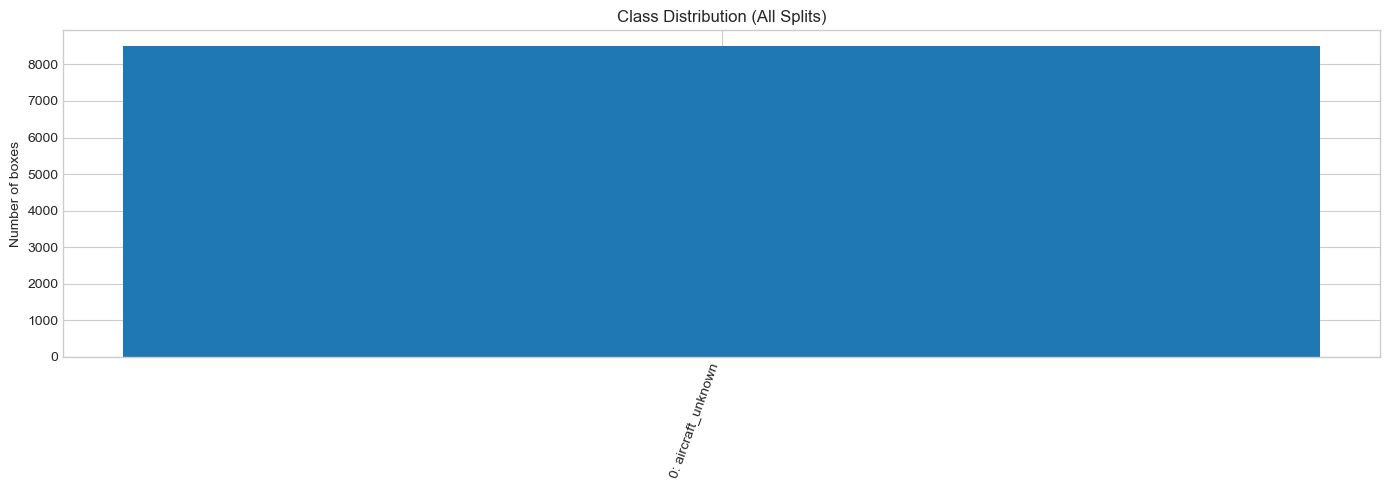

In [3]:
class_counter = Counter([row["class_id"] for row in boxes])

if not class_counter:
    print("No bounding boxes found in dataset.")
else:
    ordered = sorted(class_counter.items(), key=lambda x: x[1], reverse=True)
    labels = [f"{cls_id}: {CLASS_NAMES.get(cls_id, str(cls_id))}" for cls_id, _ in ordered]
    values = [count for _, count in ordered]

    plt.figure(figsize=(14, 5))
    plt.bar(labels, values)
    plt.xticks(rotation=70, ha="right")
    plt.ylabel("Number of boxes")
    plt.title("Class Distribution (All Splits)")
    plt.tight_layout()
    plt.show()


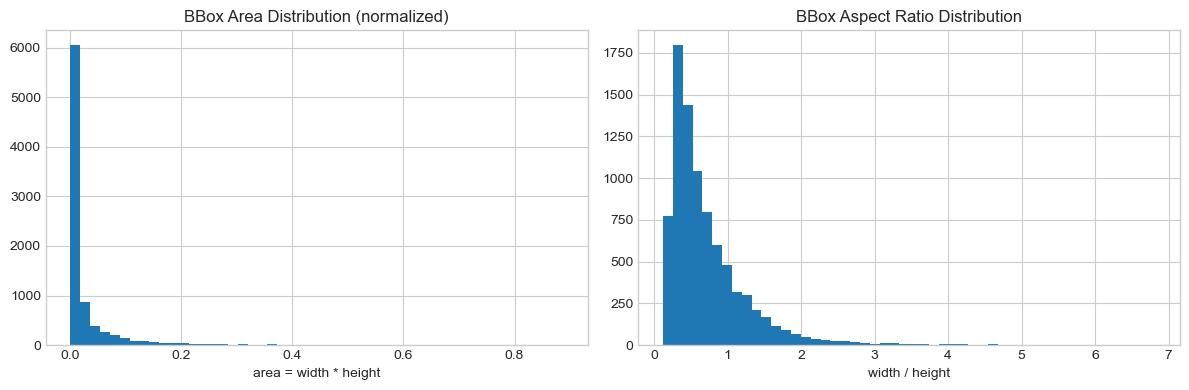

BBox area quantiles:
- q10: 0.000534
- q25: 0.001661
- q50: 0.005659
- q75: 0.023071
- q90: 0.078334


In [4]:
if not boxes:
    print("No bounding boxes found in dataset.")
else:
    areas = np.array([row["bw"] * row["bh"] for row in boxes], dtype=float)
    aspects = np.array([row["bw"] / row["bh"] for row in boxes if row["bh"] > 0], dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(areas, bins=50)
    axes[0].set_title("BBox Area Distribution (normalized)")
    axes[0].set_xlabel("area = width * height")

    axes[1].hist(aspects, bins=50)
    axes[1].set_title("BBox Aspect Ratio Distribution")
    axes[1].set_xlabel("width / height")

    plt.tight_layout()
    plt.show()

    print("BBox area quantiles:")
    for q in [0.1, 0.25, 0.5, 0.75, 0.9]:
        print(f"- q{int(q*100):02d}: {np.quantile(areas, q):.6f}")


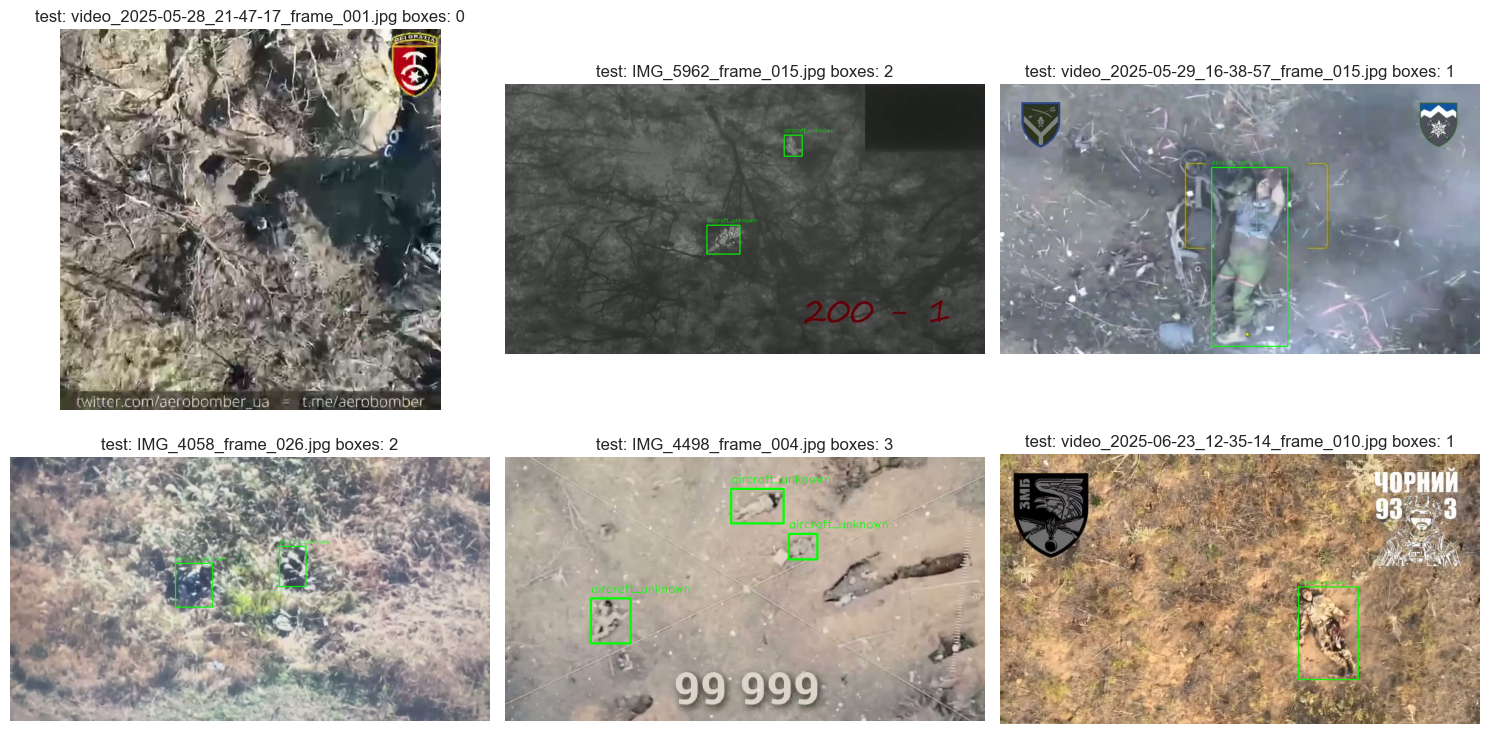

Visualized 6 images from test split


In [6]:
def read_image_unicode(path: Path):
    data = np.fromfile(str(path), dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, cv2.IMREAD_COLOR)


def draw_boxes(image_bgr, annotations):
    h, w = image_bgr.shape[:2]
    out = image_bgr.copy()

    for cls_id, xc, yc, bw, bh in annotations:
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)

        name = CLASS_NAMES.get(cls_id, str(cls_id))
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(out, name, (x1, max(0, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    return out


def show_samples(split: str = "test", n: int = 6, seed: int = 42):
    images_dir = SPLIT_TO_IMAGES[split]
    labels_dir = SPLIT_TO_LABELS[split]

    image_paths = [p for p in images_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
    if not image_paths:
        print(f"No images found for split: {split}")
        return []

    rng = random.Random(seed)
    selected = rng.sample(image_paths, k=min(n, len(image_paths)))

    cols = 3
    rows = int(np.ceil(len(selected) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for ax, image_path in zip(axes.flatten(), selected):
        image = read_image_unicode(image_path)
        label_path = labels_dir / f"{image_path.stem}.txt"
        annotations = read_yolo_labels(label_path)

        if image is None:
            ax.set_title(f"Failed to read{image_path.name}")
            ax.axis("off")
            continue

        vis = draw_boxes(image, annotations)
        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{split}: {image_path.name} boxes: {len(annotations)}")
        ax.axis("off")

    for ax in axes.flatten()[len(selected):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    return selected


sampled_images = show_samples(split="test", n=6, seed=7)
print(f"Visualized {len(sampled_images)} images from test split")


## Next Steps

- compare class distribution across individual splits
- inspect hard examples with false positives/false negatives after evaluation
- add per-class precision/recall from `metrics.json`
